### step 1:import libraries

In [22]:
df = df.drop('Car_Name', axis=1)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

### step 2:load dataset

In [25]:
df=pd.read_csv("car data.csv")
print("dataset shape:",df.shape)
df.head()

dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [28]:
print(df.columns)

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [39]:
print(df.dtypes)

Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type       int64
Transmission       int64
Owner              int64
Fuel_type          int64
dtype: object


### step 3:dataset information

In [29]:

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Driven_kms     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
 5   Selling_type   301 non-null    object 
 6   Transmission   301 non-null    object 
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.9+ KB
None


### step 4:check missing values

In [30]:
print(df.isnull().sum())

Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


### step 5:statistical summary

In [31]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### step 6:correlation heatmap

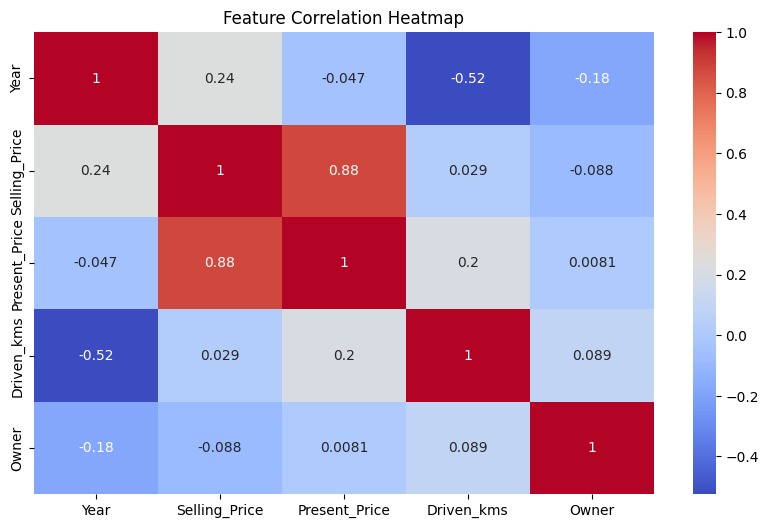

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()


### step 7:selling price Distribution

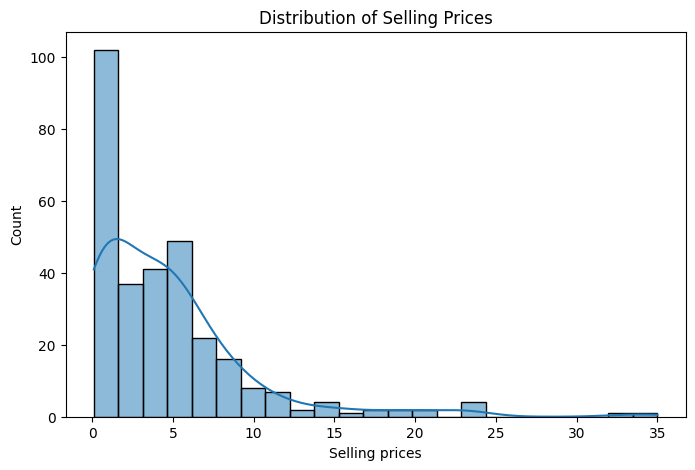

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Selling_Price'],
    kde=True
)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling prices")

plt.show()

### step 8:Fuel type analysis

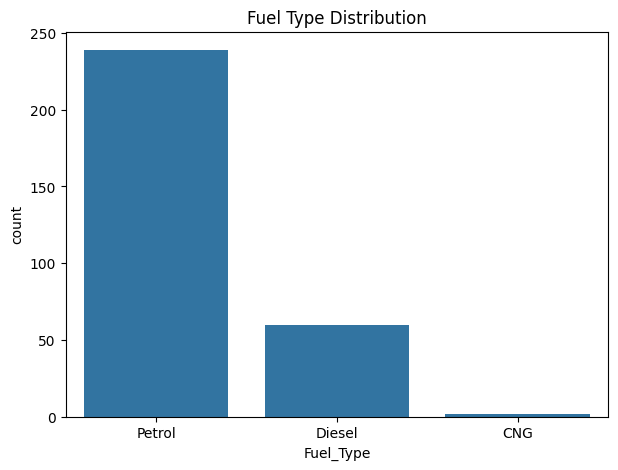

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Fuel_Type",
    data=df
)

plt.title("Fuel Type Distribution")
plt.show()

### step 9:encode categorical columns

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

### step 10:features and target

In [47]:
x=df.drop('Selling_Price',axis=1)

y=df['Selling_Price']

### step 11:Train-test-split

In [48]:
print(df.dtypes)

Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type          int64
Selling_type       int64
Transmission       int64
Owner              int64
Fuel_type          int64
Fuel_Type          int64
dtype: object


In [49]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

### step 12:linear regression model

In [66]:
lr=LinearRegression()

lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)

print("Linear Regression Score:", r2_score(y_test, y_pred))

Linear Regression: 0.8466902419662771


### step 13:random forest model

In [69]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train,y_train)

y_pred=rf.predict(x_test)

print("Random Forest R2 Score:",
     r2_score(y_test,y_pred))

Random Forest R2 Score: 0.9656356514898546


### step 14:model comparison


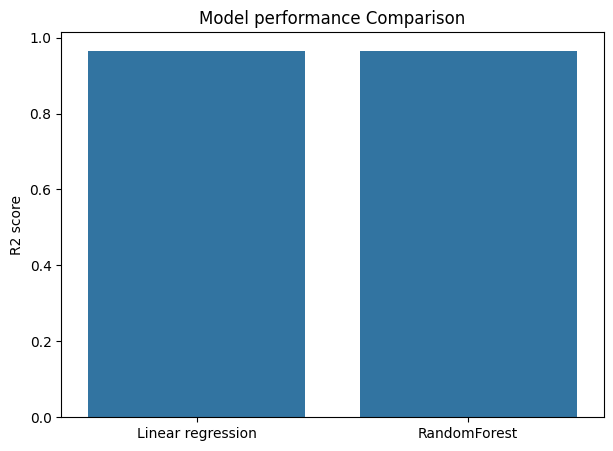

In [70]:
models=["Linear regression","RandomForest"]

scores=[
    r2_score(y_test,y_pred),
    r2_score(y_test,y_pred)
]

plt.figure(figsize=(7,5))
sns.barplot(x=models,y=scores)
    

plt.title("Model performance Comparison")
plt.ylabel("R2 score")

plt.show()

In [71]:
from sklearn.metrics import r2_score

print("Linear Regression:", r2_score(y_test, y_pred))
print("Random Forest:", r2_score(y_test, y_pred))

Linear Regression: 0.9656356514898546
Random Forest: 0.9656356514898546


### step 15:actual vs predicted

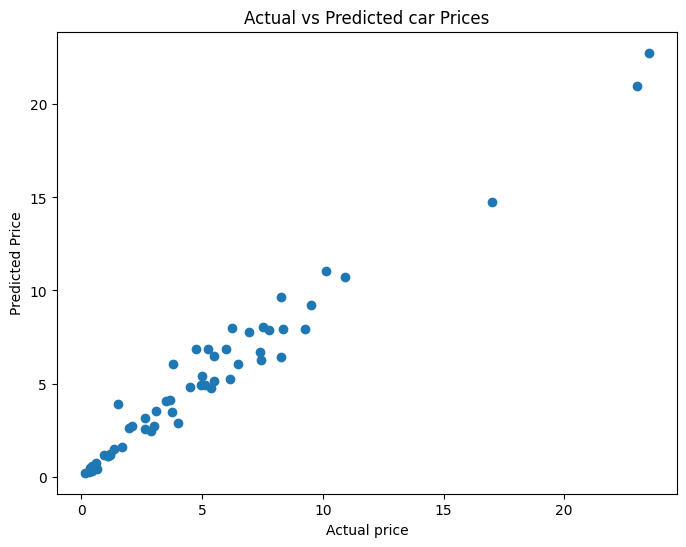

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted car Prices")

plt.show()

### step 16:predict a new car price

In [61]:
sample=x.iloc[[0]]

prediction=rf.predict(sample)
print("Predicate car Price:",
     prediction[0])

Predicate car Price: 3.8355000000000037


In [68]:
from sklearn.metrics import r2_score

print("Linear Regression:", r2_score(y_test, y_pred))
print("Random Forest:", r2_score(y_test, y_pred))

Linear Regression: 0.8466902419662771
Random Forest: 0.8466902419662771
